In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

# Example: '/content/drive/MyDrive/my_data_folder/data.csv'
S1 = pd.read_csv('/content/drive/MyDrive/CO2 CAPTURE SIMULATION/S-1.csv')
S2 = pd.read_csv('/content/drive/MyDrive/CO2 CAPTURE SIMULATION/S-2.csv')
S3 = pd.read_csv('/content/drive/MyDrive/CO2 CAPTURE SIMULATION/S-3.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


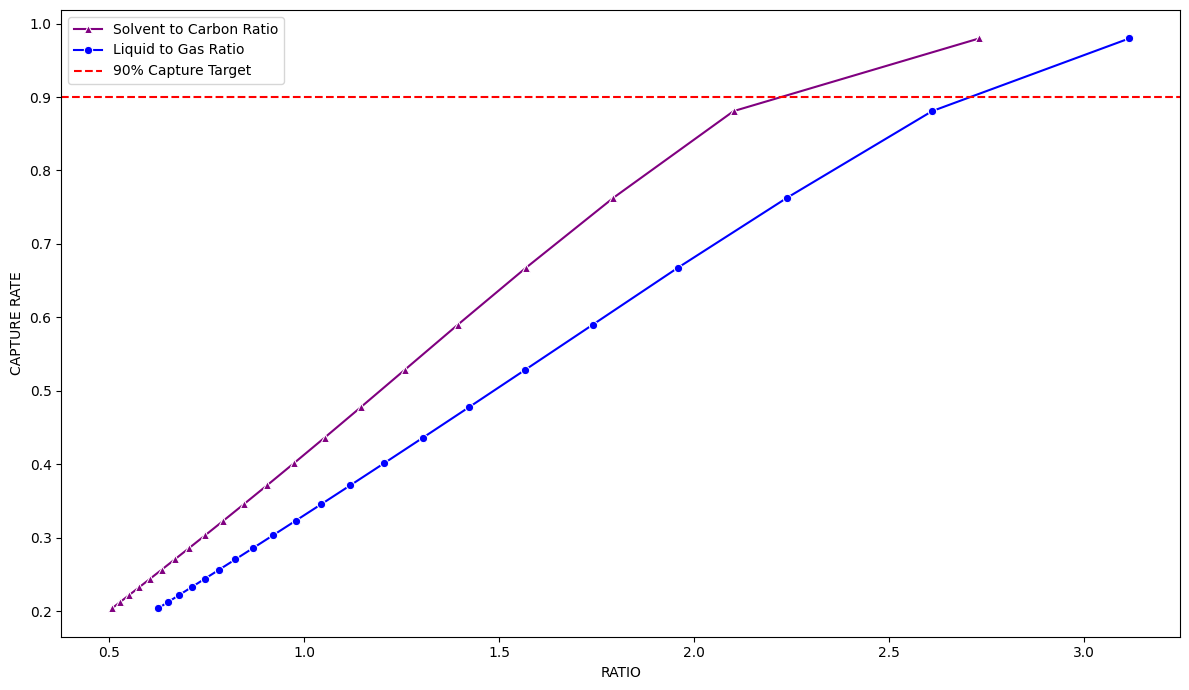

In [ ]:
# FIGURE 1
import matplotlib.pyplot as plt
import seaborn as sns

# CREATE NEW COLUMN TO SHOW CAPTURE RATE
S1['CAPTURE'] = (S1['CO2 IN (KG/SEC)'] - S1['CO2 OUT (KG/SEC)']) / (S1['CO2 IN (KG/SEC)'])

# CREATE NEW COLUMN SHOWING LIQUID TO GAS RATIO
S1['LIQUID TO GAS RATIO'] = (S1['LEANIN TOTAL (KG/SEC)']) / (S1['FLUEGAS TOTAL MASS FLOW  (KG/SEC)  \n'])
S1['SOLVENT:CARBON RATIO'] = (S1['MEA IN (KG/SEC)']) / (S1['CO2 IN (KG/SEC)'])


# PLOT L:G RATIO VERSUS CAPTURE
S1_plot = S1.sort_values(by='LIQUID TO GAS RATIO').copy()
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.lineplot(data=S1_plot, x='SOLVENT:CARBON RATIO', y='CAPTURE', ax=ax1, color='purple', marker='^', label='Solvent to Carbon Ratio')
sns.lineplot(data=S1_plot, x='LIQUID TO GAS RATIO', y='CAPTURE', ax=ax1, color='blue', marker='o', label='Liquid to Gas Ratio')
ax1.axhline(y=0.90, color='red', linestyle='--', label='90% Capture Target')
ax1.set_xlabel('RATIO')
ax1.set_ylabel('CAPTURE RATE')
ax1.legend()

plt.tight_layout()
plt.show()

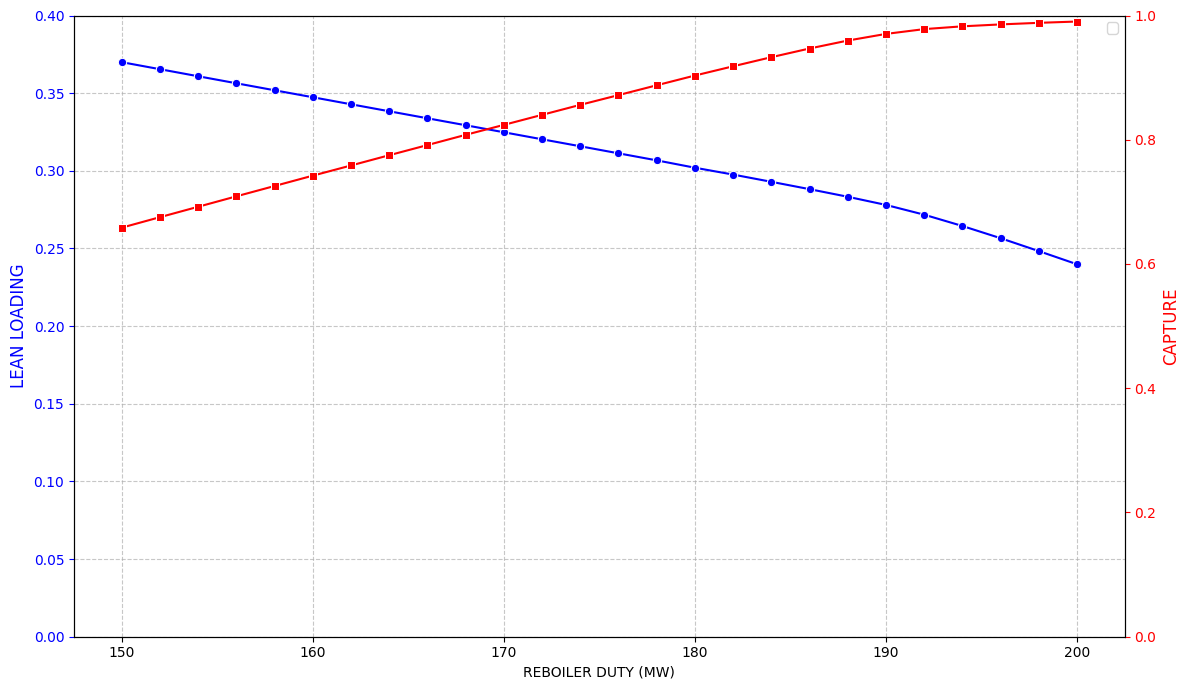

In [ ]:
# FIGURE 2
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize figure and axes for plotting
fig, ax1 = plt.subplots(figsize=(12, 7))

# CREATE NEW COLUMN REPRESENTING LEANLOADING
S2['LEAN LOADING'] = (S2['CO2 (KMOL/SEC)\n'] + S2['CO3 (KMOL/SEC)\n'] + S2['HCO3 (KMOL/SEC)\n'] + S2['MEACOO (KMOL/SEC)\n']) / (S2['MEA (KMOL/SEC)\n'] + S2['MEAH (KMOL/SEC)\n'] + S2['MEACOO (KMOL/SEC)\n'])

# CREATE NEW COLUMN REPRESENTING CAPTURE
S2['CAPTURE'] = (S2['FLUEGAS (KMOL/SEC)\n'] - S2['CLEANGAS (KMOL/SEC)\n']) / S2['FLUEGAS (KMOL/SEC)\n']

S2_plot = S2.sort_values(by='STRIPPER REBOILER DUTY (MW)').copy()

# PLOT REBOILER DUTY AGAINST CAPTURE AND LEANLOADING
sns.lineplot(x='STRIPPER REBOILER DUTY (MW)', y='LEAN LOADING', data=S2_plot, ax=ax1, color='blue', marker='o')
ax1.set_xlabel('REBOILER DUTY (MW)')
ax1.set_ylabel('LEAN LOADING', color='blue', fontsize=12)
ax1.tick_params(axis='y', colors='blue') # Set tick marks and labels to blue
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(0, 0.4)

# Create a second y-axis for Heat Duty, plotting original 'DUTY (J/SEC)'
ax2 = ax1.twinx()
sns.lineplot(x='STRIPPER REBOILER DUTY (MW)', y='CAPTURE', data=S2_plot, ax=ax2, color='red', marker='s')
ax2.set_ylabel('CAPTURE', color='red', fontsize=12)
ax2.tick_params(axis='y', colors='red') # Set tick marks and labels to red

ax2.ticklabel_format(style='plain', axis='y')
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()

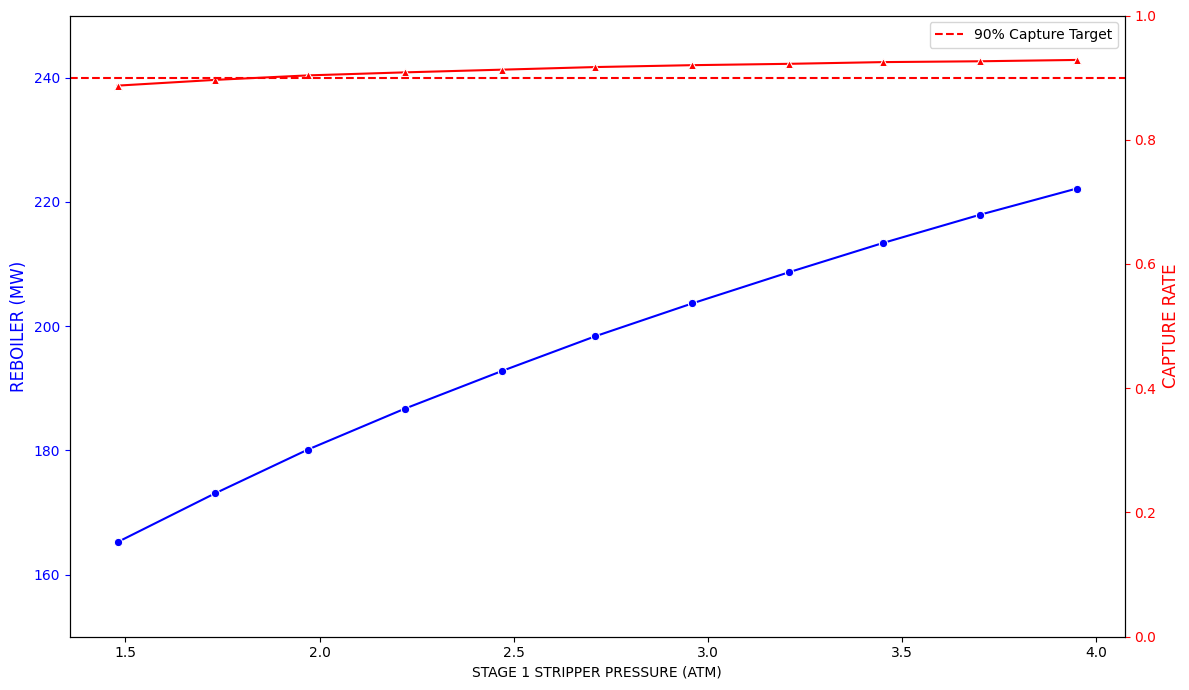

In [ ]:
# FIGURE 3
import matplotlib.pyplot as plt
import seaborn as sns

S3['CAPTURE RATE'] = (S3['CO2 IN (KG/SEC)'] - S3['CO2 OUT (KG/SEC)']) / S3['CO2 IN (KG/SEC)']

S3_plot = S3.sort_values(by='\nSTRIPPER STAGE 1\nPRESSURE (ATM)   ').copy()
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.lineplot(data=S3_plot, x='\nSTRIPPER STAGE 1\nPRESSURE (ATM)   ', y='REBOILER (MW)',ax=ax1, color='blue', marker='o')
ax1.set_xlabel('STAGE 1 STRIPPER PRESSURE (ATM)')
ax1.set_ylabel('REBOILER (MW)', color='blue', fontsize=12)
ax1.tick_params(axis='y', colors='blue')
ax1.set_ylim(150, 250)


ax2 = ax1.twinx()
sns.lineplot(data=S3_plot, x='\nSTRIPPER STAGE 1\nPRESSURE (ATM)   ', y='CAPTURE RATE',ax=ax2, color='red', marker='^')
ax2.axhline(y=0.90, color='red', linestyle='--', label='90% Capture Target')
ax2.set_ylabel('CAPTURE RATE', color='red', fontsize=12)
ax2.tick_params(axis='y', colors='red')
ax2.set_ylim(0, 1)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.tight_layout()
plt.show()